In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../data/creditcard.csv")
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
df.shape

(284807, 31)

In [5]:
df['Class'].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64

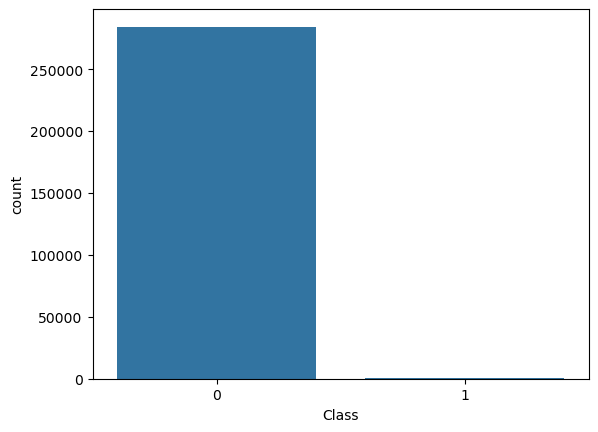

In [6]:
sns.countplot(x='Class', data=df)
plt.show()


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])


In [8]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [9]:
from imblearn.over_sampling import SMOTE


In [10]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train, y_train
)


In [11]:
pd.Series(y_train_smote).value_counts()


Class
0    227451
1    227451
Name: count, dtype: int64

In [12]:
from sklearn.linear_model import LogisticRegression

lr_smote = LogisticRegression(max_iter=1000)
lr_smote.fit(X_train_smote, y_train_smote)


LogisticRegression(max_iter=1000)

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)


RandomForestClassifier(random_state=42)

In [14]:
from sklearn.ensemble import RandomForestClassifier


In [15]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


In [16]:
y_pred = rf_smote.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[56849    15]
 [   16    82]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.84      0.84        98

    accuracy                           1.00     56962
   macro avg       0.92      0.92      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [17]:
roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:,1])


0.9731024901519414

## Real-Time Fraud Detection Simulation


In [31]:
# Take a small subset to simulate live transactions
X_live = X_test.sample(10, random_state=42)
y_live = y_test.loc[X_live.index]


In [32]:
for i in range(len(X_live)):
    transaction = X_live.iloc[i:i+1]
    actual = y_live.iloc[i]
    prediction = rf_smote.predict(transaction)[0]

    if prediction == 1:
        print(f"Transaction {i+1}: FRAUD detected (Actual: {actual})")
    else:
        print(f"Transaction {i+1}: Legitimate (Actual: {actual})")


Transaction 1: Legitimate (Actual: 0)
Transaction 2: Legitimate (Actual: 0)
Transaction 3: Legitimate (Actual: 0)
Transaction 4: Legitimate (Actual: 0)
Transaction 5: Legitimate (Actual: 0)
Transaction 6: Legitimate (Actual: 0)
Transaction 7: Legitimate (Actual: 0)
Transaction 8: Legitimate (Actual: 0)
Transaction 9: Legitimate (Actual: 0)
Transaction 10: Legitimate (Actual: 0)


### Simulation Explanation

Each transaction from the test set was passed individually 
to the trained Random Forest model to simulate real-time 
fraud detection.

The model predicts whether a transaction is fraudulent (1) 
or legitimate (0) as it arrives.


In [34]:
import joblib
joblib.dump(rf_smote, "../src/fraud_detection_model.pkl")


['../src/fraud_detection_model.pkl']